## 1. Installing Required Libraries

We install the Hugging Face Transformers and Datasets libraries along with other required machine learning libraries.

In [1]:
!pip install -q transformers datasets accelerate scikit-learn

## 2. Importing Libraries

In this step, we import the Python libraries required for data processing, model training, and evaluation.

In [1]:
import os
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


## 3. Mounting Google Drive

The dataset is stored in Google Drive, so Google Drive is mounted to access the CSV file.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 4. Loading the Dataset

The news dataset is loaded using Pandas. The dataset contains news titles and their corresponding categories.

In [3]:
FILE = "/content/drive/MyDrive/Colab Notebooks/Classification Model Using Bert and RoBerta/news.csv"

print("File exists:", os.path.exists(FILE))

df = pd.read_csv(FILE)

print("Dataset Shape:", df.shape)

df.head()

File exists: True
Dataset Shape: (4997, 10)


,URL,Title,Category,Group Leader,Original_Category,Title_Normalized,Original_Row_ID,Original_Majority,Final_Category,Label_Source
0,https://asiatimes.com/2025/10/vietnam-airlines...,Vietnam Airlines data leak exposes a crisis of...,Technology,NaN,Technology,vietnam airlines data leak exposes a crisis of...,0,Technology,Technology,TITLE
1,https://asiatimes.com/2025/10/doj-seizes-15-bi...,DOJ seizes $15 billion bitcoin in SE Asia cryp...,Markets,NaN,Markets,doj seizes $15 billion bitcoin in se asia cryp...,1,Markets,Markets,TITLE
2,https://www.fool.com/investing/2025/10/15/too-...,Think It's Too Late to Buy IonQ? Here's the 1 ...,Markets,NaN,Markets,think it's too late to buy ionq? here's the 1 ...,2,Markets,Markets,URL
3,https://www.fool.com/investing/2025/10/15/inte...,Intel's Crucial Panther Lake Chips Start Produ...,Technology,NaN,Technology,intel's crucial panther lake chips start produ...,3,Technology,Technology,TITLE
4,https://www.fool.com/investing/2025/10/15/3-ro...,3 Robotics Stocks to Buy in October,Markets,NaN,Markets,3 robotics stocks to buy in october,4,Markets,Markets,TITLE+URL


## 5. Exploring the Dataset

Before training the model, we inspect the dataset columns, data types, missing values, and category distribution.

In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['URL', 'Title', 'Category', 'Group Leader', 'Original_Category', 'Title_Normalized', 'Original_Row_ID', 'Original_Majority', 'Final_Category', 'Label_Source']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   URL                4997 non-null   object
 1   Title              4997 non-null   object
 2   Category           4997 non-null   object
 3   Group Leader       4262 non-null   object
 4   Original_Category  4997 non-null   object
 5   Title_Normalized   4997 non-null   object
 6   Original_Row_ID    4997 non-null   int64 
 7   Original_Majority  4997 non-null   object
 8   Final_Category     4997 non-null   object
 9   Label_Source       4997 non-null   object
dtypes: int64(1), object(9)
memory usage: 390.5+ KB


## 6. Selecting Input and Target Columns

For this classification task:

- `Title` is used as the input text.
- `Final_Category` is used as the target label.

In [6]:
df = df[["Title", "Final_Category"]].copy()

df.head()

,Title,Final_Category
0,Vietnam Airlines data leak exposes a crisis of...,Technology
1,DOJ seizes $15 billion bitcoin in SE Asia cryp...,Markets
2,Think It's Too Late to Buy IonQ? Here's the 1 ...,Markets
3,Intel's Crucial Panther Lake Chips Start Produ...,Technology
4,3 Robotics Stocks to Buy in October,Markets


## 7. Checking Missing Values

Missing values in the input text or target labels can cause problems during training. Therefore, missing values are identified and removed.

In [7]:
df.isnull().sum()

,0
Title,0
Final_Category,0


In [8]:
df = df.dropna(subset=["Title", "Final_Category"])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (4997, 2)


## 8. Removing Duplicate Records

Duplicate news records are removed to reduce repeated information in the dataset.

In [9]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates(
    subset=["Title", "Final_Category"]
).reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 423
Shape after removing duplicates: (4574, 2)


## 9. Exploring Target Categories

The distribution of news categories is examined before training the classification models.

In [10]:
print(df["Final_Category"].value_counts())
print(
    "Number of categories:",
    df["Final_Category"].nunique()
)
print(df["Final_Category"].unique())

Final_Category
Markets       2072
Business       850
Technology     684
Politics       621
Health         221
Energy         126
Name: count, dtype: int64
Number of categories: 6
['Technology' 'Markets' 'Health' 'Politics' 'Business' 'Energy']


## 10. Encoding Target Labels

Machine learning models require numerical target labels. Therefore, each news category is mapped to a unique integer.

In [11]:
labels = sorted(
    df["Final_Category"].unique().tolist()
)

label2id = {
    label: i
    for i, label in enumerate(labels)
}

id2label = {
    i: label
    for label, i in label2id.items()
}

print("Label to ID:")
print(label2id)

print("\nID to Label:")
print(id2label)
df["label"] = df["Final_Category"].map(label2id)

df.head()

Label to ID:
{'Business': 0, 'Energy': 1, 'Health': 2, 'Markets': 3, 'Politics': 4, 'Technology': 5}

ID to Label:
{0: 'Business', 1: 'Energy', 2: 'Health', 3: 'Markets', 4: 'Politics', 5: 'Technology'}


,Title,Final_Category,label
0,Vietnam Airlines data leak exposes a crisis of...,Technology,5
1,DOJ seizes $15 billion bitcoin in SE Asia cryp...,Markets,3
2,Think It's Too Late to Buy IonQ? Here's the 1 ...,Markets,3
3,Intel's Crucial Panther Lake Chips Start Produ...,Technology,5
4,3 Robotics Stocks to Buy in October,Markets,3


## 11. Splitting the Dataset

The dataset is divided into three subsets:

- 80% Training Set
- 10% Validation Set
- 10% Test Set

Stratified splitting is used to preserve approximately the same class distribution across all subsets.

In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 3659
Validation samples: 457
Testing samples: 458


## 12. Checking Class Distribution After Splitting

The label distribution of the training, validation, and testing datasets is inspected to verify the stratified split.

In [13]:
print("TRAIN:")
print(train_df["Final_Category"].value_counts())

print("\nVALIDATION:")
print(val_df["Final_Category"].value_counts())

print("\nTEST:")
print(test_df["Final_Category"].value_counts())

TRAIN:
Final_Category
Markets       1657
Business       680
Technology     547
Politics       497
Health         177
Energy         101
Name: count, dtype: int64

VALIDATION:
Final_Category
Markets       207
Business       85
Technology     68
Politics       62
Health         22
Energy         13
Name: count, dtype: int64

TEST:
Final_Category
Markets       208
Business       85
Technology     69
Politics       62
Health         22
Energy         12
Name: count, dtype: int64


# BERT Model

## 13. Converting Data to Hugging Face Dataset

The Pandas DataFrames are converted into Hugging Face Dataset objects so they can be efficiently tokenized and passed to the Transformer model.

In [14]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["Title", "label"]].reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_df[["Title", "label"]].reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df[["Title", "label"]].reset_index(drop=True)
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['Title', 'label'],
    num_rows: 3659
})
Dataset({
    features: ['Title', 'label'],
    num_rows: 457
})
Dataset({
    features: ['Title', 'label'],
    num_rows: 458
})


## 14. Loading the BERT Tokenizer

The pretrained `bert-base-uncased` tokenizer is used to convert news titles into tokens that can be processed by BERT.

The tokenizer converts text into:

- Token IDs
- Attention Masks

The maximum sequence length is set to 128 tokens.

In [15]:
from transformers import AutoTokenizer

BERT_MODEL_NAME = "google-bert/bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_MODEL_NAME
)
example = "Apple launches a new artificial intelligence product"

tokens = bert_tokenizer.tokenize(example)

print(tokens)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

['apple', 'launches', 'a', 'new', 'artificial', 'intelligence', 'product']


## 15. Understanding BERT Tokenization

BERT does not directly receive raw text. The tokenizer converts each news title into numerical token IDs.

Special tokens are automatically added to represent the beginning and end of the input sequence.

In [16]:
example_encoding = bert_tokenizer(
    example,
    truncation=True,
    max_length=128
)

print("Input IDs:")
print(example_encoding["input_ids"])

print("\nAttention Mask:")
print(example_encoding["attention_mask"])

Input IDs:
[101, 6207, 18989, 1037, 2047, 7976, 4454, 4031, 102]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1]


## 16. Tokenizing the Dataset

All news titles are tokenized using the pretrained BERT tokenizer. Truncation is applied to ensure that sequences do not exceed the maximum length.

In [21]:
def bert_tokenize(batch):
    return bert_tokenizer(
        batch["Title"],
        truncation=True,
        max_length=128
    )


bert_train_dataset = train_dataset.map(
    bert_tokenize,
    batched=True
)

bert_val_dataset = val_dataset.map(
    bert_tokenize,
    batched=True
)

bert_test_dataset = test_dataset.map(
    bert_tokenize,
    batched=True
)

bert_train_dataset[0]

Map:   0%|          | 0/3659 [00:00<?, ? examples/s]

Map:   0%|          | 0/457 [00:00<?, ? examples/s]

Map:   0%|          | 0/458 [00:00<?, ? examples/s]

{'Title': 'Mexico will promote mixed investment and new federal tenders in 2026',
 'label': 0,
 'input_ids': [101,
  3290,
  2097,
  5326,
  3816,
  5211,
  1998,
  2047,
  2976,
  8616,
  2015,
  1999,
  16798,
  2575,
  102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

## 17. Dynamic Padding

Dynamic padding pads the sequences within each batch to the length of the longest sequence in that batch.

This avoids unnecessary padding and reduces memory and computation requirements.

In [22]:
from transformers import DataCollatorWithPadding

bert_data_collator = DataCollatorWithPadding(
    tokenizer=bert_tokenizer
)

## 18. Loading Pretrained BERT for Sequence Classification

A pretrained BERT model is loaded with a sequence classification head.

The original BERT model provides contextual text representations, while the classification layer produces scores for the six news categories.

In [23]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)
print(bert_model)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 19. Defining Evaluation Metrics

The following metrics are used to evaluate classification performance:

- Accuracy
- Macro F1 Score
- Weighted F1 Score

Macro F1 is particularly useful for evaluating performance across all categories equally.

In [24]:
def compute_metrics(eval_pred):

    logits, true_labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        true_labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

## 20. Configuring BERT Fine-Tuning

The BERT model is fine-tuned on the news classification dataset.

Main hyperparameters:

- Learning Rate: 2e-5
- Batch Size: 16
- Epochs: 3
- Weight Decay: 0.01

The model is evaluated after every epoch, and the best model is selected using Macro F1 score.

In [25]:
from transformers import TrainingArguments

bert_training_args = TrainingArguments(
    output_dir="./bert_news_model",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_strategy="epoch",

    report_to="none",

    seed=42
)

## 21. Creating the BERT Trainer

The Hugging Face Trainer manages the fine-tuning process, including training, validation, batching, and metric calculation.

In [26]:
from transformers import Trainer

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,

    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,

    processing_class=bert_tokenizer,

    data_collator=bert_data_collator,

    compute_metrics=compute_metrics
)

## 22. Fine-Tuning BERT

The pretrained BERT model is now fine-tuned on the training dataset.

During fine-tuning, the pretrained BERT parameters and the classification head are optimized for the news category classification task.

In [27]:
bert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.092541,0.882198,0.713348,0.581211,0.699213
2,0.646075,0.737054,0.750547,0.692174,0.750750
3,0.443738,0.714066,0.772429,0.718582,0.770827


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=687, training_loss=0.7274512522779351, metrics={'train_runtime': 122.8978, 'train_samples_per_second': 89.318, 'train_steps_per_second': 5.59, 'total_flos': 187584363655776.0, 'train_loss': 0.7274512522779351, 'epoch': 3.0})

## 23. Evaluating BERT on the Test Set

After training, the best BERT model is evaluated on the unseen test dataset.

In [28]:
bert_test_results = bert_trainer.evaluate(
    bert_test_dataset
)

bert_test_results

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.443738,0.703901,3,0.777293,0.697382,0.773856


{'eval_loss': 0.7039006948471069,
 'eval_accuracy': 0.777292576419214,
 'eval_macro_f1': 0.6973824994959532,
 'eval_weighted_f1': 0.7738561506472866}

## 24. BERT Classification Report

A classification report is generated to examine precision, recall, and F1 score for each news category individually.

In [29]:
bert_predictions = bert_trainer.predict(
    bert_test_dataset
)

bert_pred_labels = np.argmax(
    bert_predictions.predictions,
    axis=-1
)

print(
    classification_report(
        bert_predictions.label_ids,
        bert_pred_labels,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    Business     0.6923    0.6353    0.6626        85
      Energy     0.6250    0.4167    0.5000        12
      Health     0.7222    0.5909    0.6500        22
     Markets     0.8394    0.8798    0.8592       208
    Politics     0.7460    0.7581    0.7520        62
  Technology     0.7397    0.7826    0.7606        69

    accuracy                         0.7773       458
   macro avg     0.7275    0.6772    0.6974       458
weighted avg     0.7732    0.7773    0.7739       458



## 25. Predicting the Category of New News

The fine-tuned BERT model can now predict the category of a new unseen news title.

In [33]:
def predict_with_bert(title):

    inputs = bert_tokenizer(
        title,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {
        key: value.to(bert_model.device)
        for key, value in inputs.items()
    }

    bert_model.eval()

    with torch.no_grad():
        outputs = bert_model(**inputs)

    prediction_id = torch.argmax(
        outputs.logits,
        dim=-1
    ).item()

    return id2label[prediction_id]
news = "Microsoft introduces a new artificial intelligence platform"

print(
    "Predicted Category:",
    predict_with_bert(news)
)

Predicted Category: Technology


## 26. BERT Results

The fine-tuned BERT model achieved the following performance on the test dataset:

- Accuracy: **77.73%**
- Macro F1 Score: **69.74%**
- Weighted F1 Score: **77.39%**

The model performed best on the **Markets** category with an F1 score of approximately **85.92%**.

The **Energy** category achieved the lowest F1 score of **50.00%**, which may be influenced by the smaller number of Energy samples compared with other categories.

# RoBERTa Model

## 27. Loading the RoBERTa Tokenizer

A pretrained RoBERTa tokenizer is loaded to prepare the news titles for the RoBERTa model.

RoBERTa uses its own tokenizer and tokenization scheme, so the dataset must be tokenized again specifically for RoBERTa.

In [34]:
from transformers import AutoTokenizer

ROBERTA_MODEL_NAME = "FacebookAI/roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    ROBERTA_MODEL_NAME
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## 28. Examining RoBERTa Tokenization

A sample news title is tokenized to observe how the RoBERTa tokenizer represents text.

In [35]:
example = "Microsoft introduces a new artificial intelligence platform"

roberta_tokens = roberta_tokenizer.tokenize(example)

print(roberta_tokens)

['Microsoft', 'Ġintroduces', 'Ġa', 'Ġnew', 'Ġartificial', 'Ġintelligence', 'Ġplatform']


## 29. Tokenizing the Dataset for RoBERTa

The training, validation, and testing datasets are tokenized using the pretrained RoBERTa tokenizer.

A maximum sequence length of 128 tokens is used.

In [36]:
def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["Title"],
        truncation=True,
        max_length=128
    )

In [37]:
roberta_train_dataset = train_dataset.map(
    roberta_tokenize,
    batched=True
)

roberta_val_dataset = val_dataset.map(
    roberta_tokenize,
    batched=True
)

roberta_test_dataset = test_dataset.map(
    roberta_tokenize,
    batched=True
)

Map:   0%|          | 0/3659 [00:00<?, ? examples/s]

Map:   0%|          | 0/457 [00:00<?, ? examples/s]

Map:   0%|          | 0/458 [00:00<?, ? examples/s]

In [38]:
roberta_train_dataset[0]

{'Title': 'Mexico will promote mixed investment and new federal tenders in 2026',
 'label': 0,
 'input_ids': [0,
  15780,
  40,
  3720,
  4281,
  915,
  8,
  92,
  752,
  3805,
  268,
  11,
  291,
  2481,
  2],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

## 30. Dynamic Padding for RoBERTa

Dynamic padding is used to pad each batch according to the longest sequence within that batch, reducing unnecessary computation.

In [39]:
from transformers import DataCollatorWithPadding

roberta_data_collator = DataCollatorWithPadding(
    tokenizer=roberta_tokenizer
)

## 31. Loading Pretrained RoBERTa for Sequence Classification

The pretrained RoBERTa model is loaded with a classification head containing six output classes corresponding to the six news categories.

In [40]:
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 32. Configuring RoBERTa Fine-Tuning

The pretrained RoBERTa model is fine-tuned on the news classification dataset.

The same major training settings used for BERT are also used for RoBERTa to make the model comparison fair.

Hyperparameters:

- Learning Rate: 2e-5
- Batch Size: 16
- Epochs: 3
- Weight Decay: 0.01

The best model is selected based on the validation Macro F1 score.

In [41]:
from transformers import TrainingArguments

roberta_training_args = TrainingArguments(
    output_dir="./roberta_news_model",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_strategy="epoch",

    report_to="none",

    seed=42
)

## 33. Creating the RoBERTa Trainer

The Hugging Face Trainer is configured using the RoBERTa model, training dataset, validation dataset, tokenizer, dynamic padding, and evaluation metrics.

In [42]:
from transformers import Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,

    train_dataset=roberta_train_dataset,
    eval_dataset=roberta_val_dataset,

    processing_class=roberta_tokenizer,

    data_collator=roberta_data_collator,

    compute_metrics=compute_metrics
)

## 34. Fine-Tuning RoBERTa

The pretrained RoBERTa model is now fine-tuned on the news classification dataset.

During training, the model learns to map contextual representations of news titles to the six target news categories.

In [43]:
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.019060,0.807369,0.726477,0.633995,0.716000
2,0.643781,0.750951,0.768053,0.724280,0.769197
3,0.480660,0.758242,0.768053,0.718385,0.767319


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=687, training_loss=0.7145003606138272, metrics={'train_runtime': 148.9672, 'train_samples_per_second': 73.687, 'train_steps_per_second': 4.612, 'total_flos': 209361696688512.0, 'train_loss': 0.7145003606138272, 'epoch': 3.0})

## 35. Evaluating RoBERTa on the Test Set

The best fine-tuned RoBERTa model is evaluated on the unseen test dataset using Accuracy, Macro F1, and Weighted F1.

In [44]:
roberta_test_results = roberta_trainer.evaluate(
    roberta_test_dataset
)

roberta_test_results

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.480660,0.725070,3,0.737991,0.656508,0.740114


{'eval_loss': 0.7250695824623108,
 'eval_accuracy': 0.7379912663755459,
 'eval_macro_f1': 0.6565076247871947,
 'eval_weighted_f1': 0.7401143955729109}

## 36. RoBERTa Classification Report

A detailed classification report is generated to analyze precision, recall, and F1 score for each individual news category.

In [45]:
roberta_predictions = roberta_trainer.predict(
    roberta_test_dataset
)

roberta_pred_labels = np.argmax(
    roberta_predictions.predictions,
    axis=-1
)

print(
    classification_report(
        roberta_predictions.label_ids,
        roberta_pred_labels,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    Business     0.5865    0.7176    0.6455        85
      Energy     0.4167    0.4167    0.4167        12
      Health     0.7222    0.5909    0.6500        22
     Markets     0.8543    0.8173    0.8354       208
    Politics     0.7097    0.7097    0.7097        62
  Technology     0.7143    0.6522    0.6818        69

    accuracy                         0.7380       458
   macro avg     0.6673    0.6507    0.6565       458
weighted avg     0.7461    0.7380    0.7401       458



## 37. RoBERTa Results

The fine-tuned RoBERTa model achieved the following performance on the test dataset:

- Accuracy: **73.80%**
- Macro F1 Score: **65.65%**
- Weighted F1 Score: **74.01%**

The highest F1 score was achieved for the **Markets** category with an F1 score of approximately **83.54%**.

The **Energy** category achieved the lowest F1 score of approximately **41.67%**. This category also contains relatively few test samples, which makes classification more difficult.

# BERT vs RoBERTa Comparison

## 38. Comparing Overall Model Performance

The BERT and RoBERTa models are compared using Accuracy, Macro F1, and Weighted F1 scores on the same test dataset.

Using the same dataset split allows a fair comparison between the two transformer models.

In [46]:
comparison_df = pd.DataFrame({
    "Model": ["BERT", "RoBERTa"],

    "Accuracy": [
        0.7773,
        0.7380
    ],

    "Macro F1": [
        0.6974,
        0.6565
    ],

    "Weighted F1": [
        0.7739,
        0.7401
    ]
})

comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,BERT,0.7773,0.6974,0.7739
1,RoBERTa,0.7380,0.6565,0.7401


## 39. Creating the Comparison Table from Evaluation Results

The evaluation results stored during testing are used to automatically generate a comparison table for BERT and RoBERTa.

In [47]:
comparison_df = pd.DataFrame({
    "Model": ["BERT", "RoBERTa"],

    "Accuracy": [
        bert_test_results["eval_accuracy"],
        roberta_test_results["eval_accuracy"]
    ],

    "Macro F1": [
        bert_test_results["eval_macro_f1"],
        roberta_test_results["eval_macro_f1"]
    ],

    "Weighted F1": [
        bert_test_results["eval_weighted_f1"],
        roberta_test_results["eval_weighted_f1"]
    ]
})

comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,BERT,0.777293,0.697382,0.773856
1,RoBERTa,0.737991,0.656508,0.740114


## 40. Model Performance in Percentage

For easier interpretation, the evaluation scores are converted into percentages.

In [48]:
comparison_percent = comparison_df.copy()

comparison_percent[
    ["Accuracy", "Macro F1", "Weighted F1"]
] *= 100

comparison_percent.round(2)

,Model,Accuracy,Macro F1,Weighted F1
0,BERT,77.73,69.74,77.39
1,RoBERTa,73.80,65.65,74.01


## 41. Visual Comparison of BERT and RoBERTa

A bar chart is used to visually compare the Accuracy, Macro F1, and Weighted F1 scores of the two models.

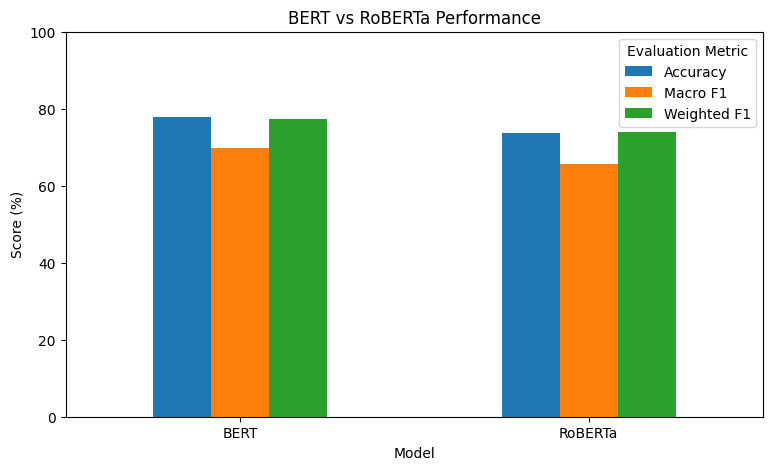

In [49]:
import matplotlib.pyplot as plt

comparison_percent.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("BERT vs RoBERTa Performance")
plt.ylabel("Score (%)")
plt.xlabel("Model")

plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metric"
)

plt.show()

# Prediction on New News

## 42. Predicting New News with RoBERTa

A prediction function is created to classify unseen news titles using the fine-tuned RoBERTa model.

In [50]:
def predict_with_roberta(title):

    inputs = roberta_tokenizer(
        title,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {
        key: value.to(roberta_model.device)
        for key, value in inputs.items()
    }

    roberta_model.eval()

    with torch.no_grad():
        outputs = roberta_model(**inputs)

    prediction_id = torch.argmax(
        outputs.logits,
        dim=-1
    ).item()

    return id2label[prediction_id]

## 43. Comparing Predictions on Unseen News

The same news title is passed to both fine-tuned models to compare their predicted categories.

In [51]:
news = "Microsoft announces new artificial intelligence technology"

print("News:")
print(news)

print("\nBERT Prediction:")
print(predict_with_bert(news))

print("\nRoBERTa Prediction:")
print(predict_with_roberta(news))

News:
Microsoft announces new artificial intelligence technology

BERT Prediction:
Technology

RoBERTa Prediction:
Technology


## 44. Testing Multiple News Headlines

Several unseen news titles are passed through the best-performing BERT model to demonstrate news category prediction.

In [52]:
sample_news = [
    "Microsoft launches a new AI-powered platform",

    "Government announces new election policy",

    "Oil prices rise after global supply concerns",

    "Doctors introduce a new treatment for heart disease",

    "Stock market reaches a record high",

    "Company reports strong quarterly revenue growth"
]

for title in sample_news:

    prediction = predict_with_bert(title)

    print("News:", title)
    print("Predicted Category:", prediction)
    print("-" * 60)

News: Microsoft launches a new AI-powered platform
Predicted Category: Technology
------------------------------------------------------------
News: Government announces new election policy
Predicted Category: Politics
------------------------------------------------------------
News: Oil prices rise after global supply concerns
Predicted Category: Markets
------------------------------------------------------------
News: Doctors introduce a new treatment for heart disease
Predicted Category: Health
------------------------------------------------------------
News: Stock market reaches a record high
Predicted Category: Markets
------------------------------------------------------------
News: Company reports strong quarterly revenue growth
Predicted Category: Markets
------------------------------------------------------------


# Conclusion

In this project, pretrained BERT and RoBERTa transformer models were fine-tuned for multi-class news category classification.

The models classified news titles into six categories:

- Business
- Energy
- Health
- Markets
- Politics
- Technology

BERT achieved an accuracy of **77.73%**, a Macro F1 score of **69.74%**, and a Weighted F1 score of **77.39%**.

RoBERTa achieved an accuracy of **73.80%**, a Macro F1 score of **65.65%**, and a Weighted F1 score of **74.01%**.

Based on the experimental results, **BERT performed better than RoBERTa on this dataset**.

Both models achieved their strongest performance on the Markets category, while the Energy category was comparatively more difficult to classify.

The results also indicate that class imbalance may influence model performance, particularly for categories containing fewer training examples.